## Imports and load data

In [1]:
from sqlalchemy import create_engine
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn import preprocessing, model_selection, linear_model, metrics
import warnings

warnings.filterwarnings('ignore')  # Ignore warnings to avoid clutter in notebook

# Load all datasets
engine = create_engine('sqlite:///db/olist.db')
customers = pd.read_csv('data/olist_customers_dataset.csv')
geolocations = pd.read_csv('data/olist_geolocation_dataset.csv')
order_items = pd.read_csv('data/olist_order_items_dataset.csv')
payments = pd.read_csv('data/olist_order_payments_dataset.csv')
reviews = pd.read_csv('data/olist_order_reviews_dataset.csv')
orders = pd.read_csv('data/olist_orders_dataset.csv')
products = pd.read_csv('data/olist_products_dataset.csv')
sellers = pd.read_csv('data/olist_sellers_dataset.csv')
categories = pd.read_csv('data/product_category_name_translation.csv')

dataset_map = {
    'customers': customers, 
    'geolocations': geolocations,
    'order_items': order_items, 
    'payments': payments,
    'reviews': reviews, 
    'orders': orders,
    'products': products, 
    'sellers': sellers, 
    'categories': categories
    }

# Data Cleaning

In [2]:
# Check null values in each dataset to determine whether to delete or impute
for name, df in dataset_map.items():
    null_count = df.isnull().sum()
    null_count = null_count[null_count > 0]
    if not null_count.empty:
        print(f"Number of rows in {name}: {len(df)}")
        print(f"{name} - Null Values:\n{null_count}\n")

Number of rows in reviews: 99224
reviews - Null Values:
review_comment_title      87656
review_comment_message    58247
dtype: int64

Number of rows in orders: 99441
orders - Null Values:
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

Number of rows in products: 32951
products - Null Values:
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64



The reviews dataset has two columns with high null counts: review_comment_title (88.3%) will be dropped, while review_comment_message (58.7%) will be kept for potential sentiment analysis later on in the project. A boolean `has_review_message` column will also be created to flag whether a customer left a review message. This makes it easier for filtering and analysis

In the orders dataset, three date columns have null rates under 3%, which likely reflects cancelled or undelivered orders. These rows will be dropped as the proportion is insignificant.

The products dataset has 610 rows missing across four descriptive columns (1.85%) which will be dropped, and the 2 nulls in the dimension columns will be resolved through median imputation.

In [3]:
# Reviews
reviews.drop(columns=['review_comment_title'], inplace=True)
reviews['has_review_message'] = reviews['review_comment_message'].notna() # Add boolean flag

# Orders
orders.dropna(subset=['order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date'], inplace=True)

# Products 
products.dropna(subset=['product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty'], inplace=True)

# Products
products.fillna(products.median(numeric_only=True), inplace=True) # Impute NA values with median

In [4]:
# Given the orders dataset uses a brand new customer_id for each order, I will perform a left join on the customer dataset, adding the customer_unique_id to matches on the existing customer_id.
# This helps us track repeat customers and their orders
orders = orders.merge(customers[['customer_id', 'customer_unique_id']], on='customer_id', how='left')

# Explatory Data Analysis

In [24]:
# Dimensions for each datasets (rows, columns)
for name, dataset in dataset_map.items():
    print(f"For {name}: {dataset.shape}")
    print(dataset.describe())

For customers: (99441, 5)
       customer_zip_code_prefix
count              99441.000000
mean               35137.474583
std                29797.938996
min                 1003.000000
25%                11347.000000
50%                24416.000000
75%                58900.000000
max                99990.000000
For geolocations: (1000163, 5)
       geolocation_zip_code_prefix  geolocation_lat  geolocation_lng
count                 1.000163e+06     1.000163e+06     1.000163e+06
mean                  3.657417e+04    -2.117615e+01    -4.639054e+01
std                   3.054934e+04     5.715866e+00     4.269748e+00
min                   1.001000e+03    -3.660537e+01    -1.014668e+02
25%                   1.107500e+04    -2.360355e+01    -4.857317e+01
50%                   2.653000e+04    -2.291938e+01    -4.663788e+01
75%                   6.350400e+04    -1.997962e+01    -4.376771e+01
max                   9.999000e+04     4.506593e+01     1.211054e+02
For order_items: (112650, 7)
     

Having a look at the statistical summary of each numerical column helps us better understand the distribution of the data, and identify any outliers that I would need to address.

In the payments data, payment_value has a mean of R$154, but a maximum value of R$13664. Given we see that the 75% percentile is at R$171, this is definitely an outlier, but more so a reflection on a small number of high-value purchases. We also see that the minimum value for payment_installments is 0 - which might suggests that nulls (no payment installments) were encoded as zeros.

From the order_items datasets, we see that the price of orders range from R$0.85 to R$6735, with an interquartile range of R$40 and R$140. This range gives us a sense of the most common price range customers purchase within. More poignant is the fact that customers mostly buy only 1 line item. This suggests customers are largely making single, purposeful purchases rather than browsing and adding multiple items.

Finally, the review scores are strongly skewed toward positive ratings with a mean of 4.1 and a median of 5. This suggests that the low-score reviews represent a small but valuable group to analyse - we will look into this further in our sentiment analysis.

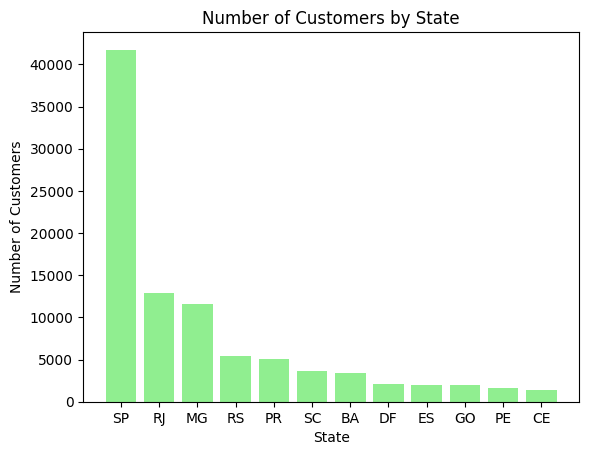

: 

In [ ]:
top8_states = customers['customer_state'].value_counts().head(12)

plt.bar(top8_states.index, top8_states.values, color='lightgreen')
plt.xlabel('State')
plt.ylabel('Number of Customers')
plt.title('Number of Customers by State')
plt.show()